/tmp/ipykernel_5672/1146603111.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.400520  72.460784  71.156682  71.409785  135480400
2020-01-03  71.696648  72.455966  71.472469  71.629153  146322800
2020-01-06  72.267937  72.306506  70.568510  70.819208  118387200
2020-01-07  71.928047  72.533087  71.708687  72.277571  108872000
2020-01-08  73.085129  73.386446  71.631574  71.631574  132079200


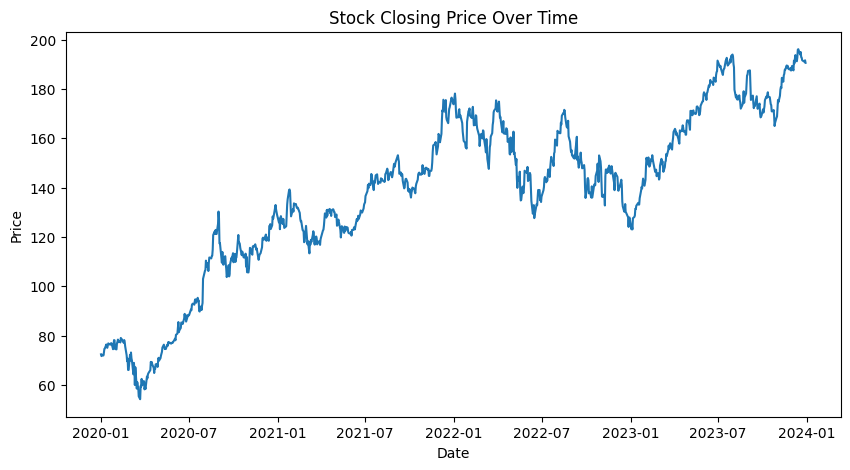

----- Linear Regression -----
MAE: 1.6542203365674133
RMSE: 2.2239481842316358

----- Random Forest -----
MAE: 7.518932400224223
RMSE: 10.369715430382408


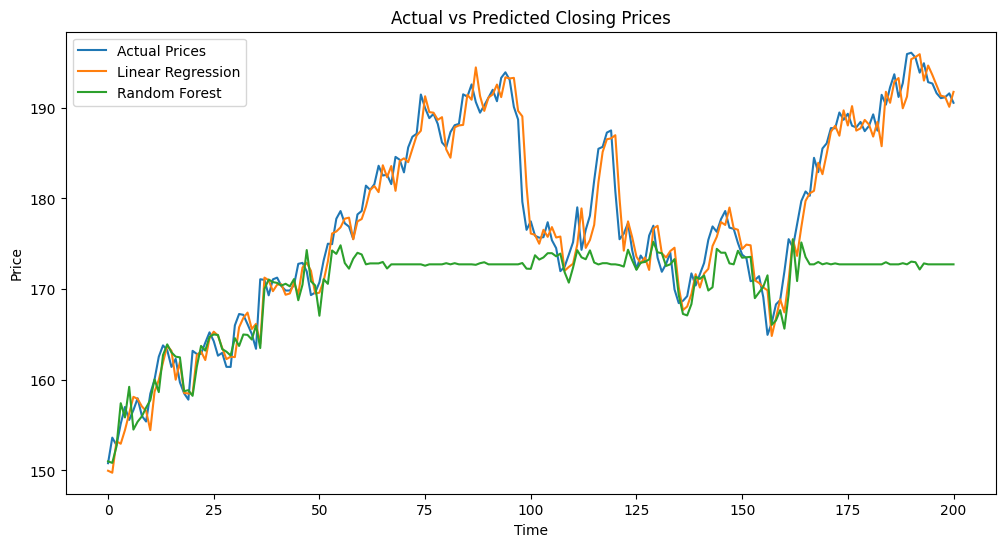

In [1]:
# =========================================
# 1. Import Libraries
# =========================================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


# =========================================
# 2. Load Stock Data (API आधारित, no dataset download)
# =========================================
stock = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

# Preview data
print(stock.head())


# =========================================
# 3. Data Exploration (Visualization)
# =========================================
plt.figure(figsize=(10,5))
plt.plot(stock['Close'])
plt.title("Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()


# =========================================
# 4. Data Preprocessing
# =========================================
# Create target variable (next day's closing price)
stock['Next_Close'] = stock['Close'].shift(-1)

# Remove last row (NaN)
stock = stock.dropna()


# =========================================
# 5. Feature Selection
# =========================================
X = stock[['Open', 'High', 'Low', 'Volume']]
y = stock['Next_Close']


# =========================================
# 6. Train-Test Split (Time Series Handling)
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


# =========================================
# 7. Linear Regression Model
# =========================================
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)


# =========================================
# 8. Random Forest Model
# =========================================
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)


# =========================================
# 9. Evaluation
# =========================================
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("----- Linear Regression -----")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)

print("\n----- Random Forest -----")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)


# =========================================
# 10. Plot: Actual vs Predicted (FINAL REQUIRED GRAPH)
# =========================================
# Fix index alignment
y_test_plot = y_test.reset_index(drop=True)
y_pred_lr_plot = pd.Series(y_pred_lr)
y_pred_rf_plot = pd.Series(y_pred_rf)

plt.figure(figsize=(12,6))

plt.plot(y_test_plot, label="Actual Prices")
plt.plot(y_pred_lr_plot, label="Linear Regression")
plt.plot(y_pred_rf_plot, label="Random Forest")

plt.title("Actual vs Predicted Closing Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()

plt.show()